 # Credit Risk Project 

### PHASE 1: PROJECT PLANNING & SETUP

##### Step 1: Project scope

### Project Overview: Define the Scope and Project Overview

Credit Risk Prediction Model (Finance)

**Objective:**  
Predict whether a borrower will default on a loan using open financial data.

**Business Goal:**  
Help financial institutions reduce default rates and optimize lending decisions.

**Data Science Goal:**  
Build and evaluate machine learning models — **Logistic Regression**, **Random Forest**, and **XGBoost** — to classify loans as “default” or “non-default”.

**Dataset:**  
Lending Club public dataset (`loan.csv`) and its data dictionary (`LCDataDictionary.xlsx`).

**Key Features:**  
- Loan amount  
- Term  
- Interest rate  
- Income  
- Debt-to-income ratio (DTI)  
- Credit history  
- Employment length  
- Revolving utilization  

**Target Variable:**  
`loan_status`  
- 0 → Non-default  
- 1 → Default  

**Evaluation Metrics:**  
- ROC-AUC  
- Precision, Recall, and F1-score  
- Confusion Matrix  

**Deliverables:**  
- ✅ Cleaned and feature-engineered dataset  
- ✅ Trained ML models with tuned hyperparameters  
- ✅ Model performance report (AUC, confusion matrix, feature importances)  
- ✅ Power BI dashboard showing:  
  - Risk segmentation (low, medium, high)  
  - Defaults by feature (e.g., income bracket, credit grade)  
  - Top drivers of default







##### Step 1b: Environment Setup/ Import Libraries

In [17]:
# Data manipulation libraries
import pandas as pd  # for handling tabular data (DataFrames), reading/writing CSV/Excel files
import numpy as np   # for numerical operations, arrays, mathematical functions

# Visualization libraries
import matplotlib.pyplot as plt  # base plotting library in Python
import seaborn as sns            # advanced plotting, works well with pandas

# Machine Learning libraries from scikit-learn and xgboost
from sklearn.model_selection import train_test_split, GridSearchCV  # for splitting data & hyperparameter tuning
from sklearn.linear_model import LogisticRegression  # basic model for binary classification
from sklearn.ensemble import RandomForestClassifier  # ensemble model for classification
from xgboost import XGBClassifier  # gradient boosting classifier, powerful for tabular data
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix  # evaluation metrics
from sklearn.preprocessing import LabelEncoder, StandardScaler  # data preprocessing

# Make plots render directly in the notebook
%matplotlib inline

# Ignore warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

### PHASE 2: DATA PREPARATION & EXPLORATION

##### Step 2: Load Dataset 
Data Collection: Gather relevant data from various sources.

In [5]:
# Load the main CSV dataset into a pandas DataFrame
data = pd.read_csv('../data/loan.csv')  

#####  Step 2a : Load the Data Dictionary


In [6]:
# Load LCDataDictionary.xlsx
data_dict = pd.read_excel('../data/LCDataDictionary.xlsx')  

# Show first 10 rows
data_dict.head(10)

,LoanStatNew,Description
0,acc_now_delinq,The number of accounts on which the borrower i...
1,acc_open_past_24mths,Number of trades opened in past 24 months.
2,addr_state,The state provided by the borrower in the loan...
3,all_util,Balance to credit limit on all trades
4,annual_inc,The self-reported annual income provided by th...
5,annual_inc_joint,The combined self-reported annual income provi...
6,application_type,Indicates whether the loan is an individual ap...
7,avg_cur_bal,Average current balance of all accounts
8,bc_open_to_buy,Total open to buy on revolving bankcards.
9,bc_util,Ratio of total current balance to high credit/...


##### Step 3: Step 3: Exploratory Data Analysis (EDA)

## PHASE 3: DATA CLEANING & FEATURE ENGINEERING

##### Step 4: Data Cleaning & Preprocessing
 Clean, format, and prepare the data for analysis.

In [7]:
# Quick look at the first 5 rows of the dataset
# Helps verify that the data loaded correctly and shows sample values
data.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Get a concise summary of the DataFrame
# Includes number of rows, column names, data types, non-null counts, and memory usage
# Very useful for detecting missing values or wrong data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), object(36)
memory usage: 2.4+ GB


In [16]:
# List all column names (even non-numerical ones
print(data.columns.tolist())


['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_i

In [9]:
# View basic statistical summary of numeric columns
# Gives mean, min, max, standard deviation, and quartiles
# Useful to understand distributions and spot potential outliers
data.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,url,dti,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,0.0,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,0.0,2.258957e+06,...,10613.0,10613.000000,10613.0,10613.000000,8426.000000,10613.000000,10613.000000,33056.000000,33056.000000,33056.000000
mean,NaN,NaN,1.504693e+04,1.504166e+04,1.502344e+04,1.309291e+01,4.458076e+02,7.799243e+04,NaN,1.882420e+01,...,3.0,155.006696,3.0,13.686422,454.840802,11628.036442,193.606331,5030.606922,47.775600,13.148596
std,NaN,NaN,9.190245e+03,9.188413e+03,9.192332e+03,4.832114e+00,2.671737e+02,1.126962e+05,NaN,1.418333e+01,...,0.0,129.113137,0.0,9.728138,375.830737,7615.161123,198.694368,3692.027842,7.336379,8.192319
min,NaN,NaN,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,NaN,-1.000000e+00,...,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.010000,44.210000,0.200000,0.000000
25%,NaN,NaN,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,NaN,1.189000e+01,...,3.0,59.370000,3.0,5.000000,174.967500,5628.730000,43.780000,2227.000000,45.000000,6.000000
50%,NaN,NaN,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,NaN,1.784000e+01,...,3.0,119.040000,3.0,15.000000,352.605000,10044.220000,132.890000,4172.855000,45.000000,14.000000
75%,NaN,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,NaN,2.449000e+01,...,3.0,213.260000,3.0,22.000000,622.792500,16114.940000,284.180000,6870.782500,50.000000,18.000000
max,NaN,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,NaN,9.990000e+02,...,3.0,943.940000,3.0,37.000000,2680.890000,40306.410000,1407.860000,33601.000000,521.350000,181.000000


In [10]:
# Print the number of rows and columns in the dataset
# Helps us quickly understand the dataset's size
print("\nShape of dataset:", data.shape)


Shape of dataset: (2260668, 145)


In [11]:
# Check for duplicate rows
print("\nNumber of duplicate rows:", data.duplicated().sum())


Number of duplicate rows: 0


In [12]:
# Remove duplicate rows (if any)
# Although none were found, this step is included in case future updates or merges introduce duplicates
data.drop_duplicates(inplace=True)
print("Duplicates removed (if any). New shape:", data.shape)

Duplicates removed (if any). New shape: (2260668, 145)


In [13]:
# Quick summary of missing data
missing = data.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Columns with missing values:\n", missing)

Columns with missing values:
 id                                            2260668
member_id                                     2260668
url                                           2260668
orig_projected_additional_accrued_interest    2252242
hardship_amount                               2250055
                                               ...   
earliest_cr_line                                   29
pub_rec                                            29
open_acc                                           29
annual_inc                                          4
zip_code                                            1
Length: 113, dtype: int64


In [14]:
# Fill or drop depending on column meaning
# Example: fill numeric columns with median
num_cols = data.select_dtypes(include=np.number).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# For categorical columns, fill with 'Unknown'
cat_cols = data.select_dtypes(include='object').columns
data[cat_cols] = data[cat_cols].fillna('Unknown')

#vs
# Convert categorical variables to proper type (optional)
categorical_cols = data.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    data[col] = data[col].astype('category')

##### Step 3: Exploratory Data Analysis (EDA): Explore the data to understand its characteristics.

3a. Target variable analysis


Loan Status Distribution:


loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

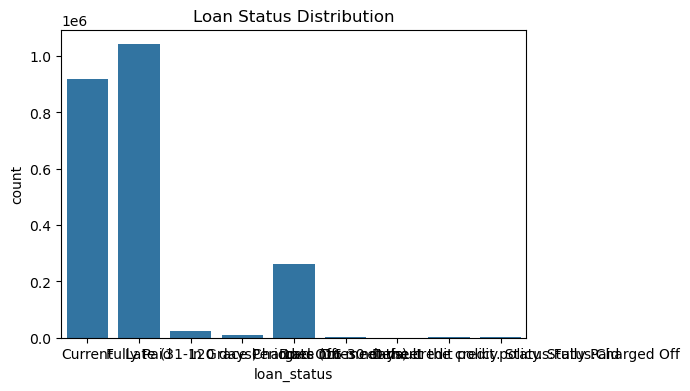

In [35]:
print("\nLoan Status Distribution:")
display(data['loan_status'].value_counts())

# Visualize target variable balance
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=data)
plt.title("Loan Status Distribution")
plt.show()

3b. Numeric feature exploration

In [ ]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
print("\nNumeric Columns:", numeric_cols)

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col].dropna(), kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

 3c. Categorical feature exploration

In [ ]:
print("\nCategorical Columns:", categorical_cols)

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=col, data=data, order=data[col].value_counts().index)
    plt.title(f"Count of Categories in {col}")
    plt.show()


3d. Missing data heatmap (optional for smaller datasets)


plt.figure(figsize=(12,6))
sns.heatmap(data.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()

##### Step 4: Feature Engineering & Scaling : Create new features or transform existing ones to improve model performance.

In [18]:
#Remove irrelevant or non-predictive columns
drop_cols = ['id', 'member_id', 'url', 'desc', 'title']
data = data.drop(columns=[c for c in drop_cols if c in data.columns], errors='ignore')

print(f"Removed irrelevant columns. Remaining columns: {data.shape[1]}")

Removed irrelevant columns. Remaining columns: 140


In [19]:
# Handle the target variable
# Convert loan_status into a binary variable: 1 = defaulted/charged-off, 0 = paid
if 'loan_status' in data.columns:
    data['default'] = data['loan_status'].apply(
        lambda x: 1 if str(x).lower() in ['charged off', 'default'] else 0
    )
    print("Created binary target column: 'default' (1 = default, 0 = paid)")
else:
    print("⚠️  'loan_status' column not found!")


Created binary target column: 'default' (1 = default, 0 = paid)


In [20]:
# Convert date columns to datetime format
date_cols = [
    'issue_d', 'earliest_cr_line', 'last_pymnt_d', 'next_pymnt_d',
    'last_credit_pull_d', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'settlement_date'
]

for col in date_cols:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors='coerce')


In [21]:
# Create new date-based features
# Example: loan issue year, and credit history length (in days)
if {'issue_d', 'earliest_cr_line'}.issubset(data.columns):
    data['issue_year'] = data['issue_d'].dt.year
    data['credit_history_length'] = (
        data['issue_d'] - data['earliest_cr_line']
    ).dt.days
    print("Created 'issue_year' and 'credit_history_length' features.")


TypeError: cannot subtract DatetimeArray from Categorical

In [ ]:
#  Encode categorical features
# Choose important categorical columns (reduce noise from 100+ total)
categorical_cols = [
    'term', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
    'verification_status', 'purpose', 'addr_state',
    'application_type', 'initial_list_status',
    'pymnt_plan', 'disbursement_method', 'debt_settlement_flag',
    'hardship_flag'
]

for col in categorical_cols:
    if col in data.columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))

print("Categorical columns encoded successfully.")

In [ ]:
# Create derived numerical ratios (optional but helpful)------------------------------------------------------------
if {'loan_amnt', 'annual_inc'}.issubset(data.columns):
    data['loan_to_income'] = data['loan_amnt'] / (data['annual_inc'] + 1)
    print("Created new ratio feature: 'loan_to_income'.")

In [ ]:
# Select numeric columns for scaling-----------------------------------------------------------
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
# Exclude target variable(s) from scaling
numeric_cols = [c for c in numeric_cols if c not in ['default']]

In [ ]:
# Scale numerical features
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])
print(f"Scaled {len(numeric_cols)} numeric features using StandardScaler.")

In [ ]:
# Verify result
print("\nData after feature engineering and scaling:")
print(data.head())
print("\nShape after feature engineering:", data.shape)

##### Step 5: Modeling: Build and train machine learning models

##### Step 6: Evaluation: Assess model performance using appropriate metrics

##### Step 7: Deployment: Implement the model into production.

##### Step 8: Monitoring and Maintenance: Continuously monitor the model’s performance and update as needed